# Multi-Class Plant Leaf Disease Classification Using CNNs and Transfer Learning

Dataset: Kaggle emmarex/plantdisease — PlantVillage

Scope: All 15 available classes across bell pepper, potato and tomato.

## Research question

How effectively can CNN-based deep-learning models classify multiple plant leaf diseases across pepper, potato and tomato plants, and how do architecture, optimizer choice, regularisation, data augmentation and transfer learning affect classification performance?

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/emmarex/plantdisease


In [2]:
import os

DATASET_PATH = "/kaggle/input/plantvillage/PlantVillage"

for root, dirs, files in os.walk("/kaggle/input"):
    if "Tomato_healthy" in dirs:
        DATASET_PATH = root
        break

print("Dataset path:", DATASET_PATH)

classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Number of classes:", len(classes))

for cls in classes:
    count = len([
        f for f in os.listdir(os.path.join(DATASET_PATH, cls))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(f"{cls:<45} {count}")

Dataset path: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage
Number of classes: 15
Pepper__bell___Bacterial_spot                 997
Pepper__bell___healthy                        1478
Potato___Early_blight                         1000
Potato___Late_blight                          1000
Potato___healthy                              152
Tomato_Bacterial_spot                         2127
Tomato_Early_blight                           1000
Tomato_Late_blight                            1909
Tomato_Leaf_Mold                              952
Tomato_Septoria_leaf_spot                     1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
Tomato__Target_Spot                           1404
Tomato__Tomato_YellowLeaf__Curl_Virus         3208
Tomato__Tomato_mosaic_virus                   373
Tomato_healthy                                1591


In [3]:
import os, gc, time, random, warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Locate PlantVillage and discover all classes dynamically

In [4]:
def find_plantvillage(search_root="/kaggle/input"):
    for root, dirs, files in os.walk(search_root):
        # The selected Kaggle dataset contains these characteristic folders.
        if "Tomato_healthy" in dirs and "Potato___healthy" in dirs:
            return root
    raise FileNotFoundError(
        "PlantVillage folder not found. Add emmarex/plantdisease as a Kaggle Input."
    )

DATASET_PATH = find_plantvillage()
CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
NUM_CLASSES = len(CLASS_NAMES)

print("Dataset path:", DATASET_PATH)
print("Number of classes:", NUM_CLASSES)
for i, cls in enumerate(CLASS_NAMES):
    print(f"{i:2d}: {cls}")

Dataset path: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage
Number of classes: 15
 0: Pepper__bell___Bacterial_spot
 1: Pepper__bell___healthy
 2: Potato___Early_blight
 3: Potato___Late_blight
 4: Potato___healthy
 5: Tomato_Bacterial_spot
 6: Tomato_Early_blight
 7: Tomato_Late_blight
 8: Tomato_Leaf_Mold
 9: Tomato_Septoria_leaf_spot
10: Tomato_Spider_mites_Two_spotted_spider_mite
11: Tomato__Target_Spot
12: Tomato__Tomato_YellowLeaf__Curl_Virus
13: Tomato__Tomato_mosaic_virus
14: Tomato_healthy


## Build image index and check integrity

All supported image files are indexed. Each image is opened and verified before it is included in the experiment.

In [5]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

records = []
for class_name in CLASS_NAMES:
    class_dir = Path(DATASET_PATH) / class_name
    for file in class_dir.iterdir():
        if file.suffix.lower() in VALID_EXTENSIONS:
            records.append({"filepath": str(file), "class_name": class_name})

df = pd.DataFrame(records)
print("Candidate images:", len(df))
display(df.head())

Candidate images: 20638


,filepath,class_name
0,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot
1,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot
2,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot
3,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot
4,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot


In [6]:
from tqdm.auto import tqdm
from PIL import Image

valid_rows = []
corrupt_files = []

for idx, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="Checking images"
):
    try:
        with Image.open(row["filepath"]) as img:
            img.verify()
        valid_rows.append(idx)
    except Exception:
        corrupt_files.append(row["filepath"])

df = df.loc[valid_rows].reset_index(drop=True)

print("\nIntegrity Check Complete")
print(f"Usable images: {len(df)}")
print(f"Corrupt images: {len(corrupt_files)}")

if corrupt_files:
    print("\nCorrupt files:")
    for file in corrupt_files[:10]:
        print(file)

Checking images:   0%|          | 0/20638 [00:00<?, ?it/s]


Integrity Check Complete
Usable images: 20638
Corrupt images: 0


## Exploratory Data Analysis and class imbalance

In [7]:
class_counts = df["class_name"].value_counts().reindex(CLASS_NAMES)
class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Images": class_counts.values,
    "Percentage": 100 * class_counts.values / class_counts.sum()
}).sort_values("Images", ascending=False)

display(class_distribution.style.format({"Percentage": "{:.2f}%"}))

print("Total images:", int(class_counts.sum()))
print("Largest class:", class_counts.idxmax(), int(class_counts.max()))
print("Smallest class:", class_counts.idxmin(), int(class_counts.min()))
print("Largest/smallest ratio:", round(class_counts.max()/class_counts.min(), 2))

,Class,Images,Percentage
12,Tomato__Tomato_YellowLeaf__Curl_Virus,3208,15.54%
5,Tomato_Bacterial_spot,2127,10.31%
7,Tomato_Late_blight,1909,9.25%
9,Tomato_Septoria_leaf_spot,1771,8.58%
10,Tomato_Spider_mites_Two_spotted_spider_mite,1676,8.12%
14,Tomato_healthy,1591,7.71%
1,Pepper__bell___healthy,1478,7.16%
11,Tomato__Target_Spot,1404,6.80%
2,Potato___Early_blight,1000,4.85%
3,Potato___Late_blight,1000,4.85%


Total images: 20638
Largest class: Tomato__Tomato_YellowLeaf__Curl_Virus 3208
Smallest class: Potato___healthy 152
Largest/smallest ratio: 21.11


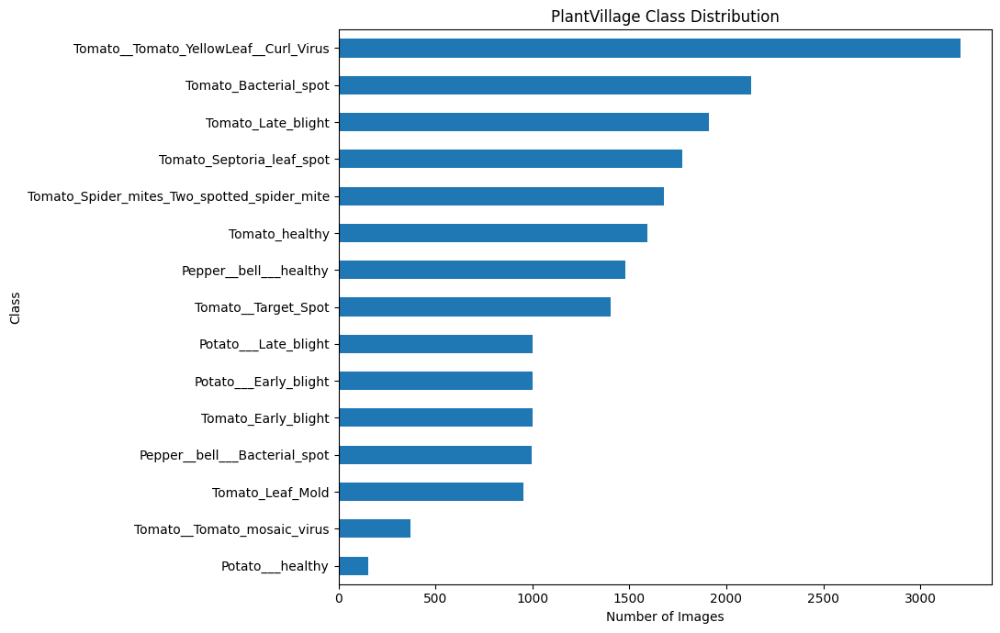

In [8]:
plt.figure(figsize=(11, 7))
class_counts.sort_values().plot(kind="barh")
plt.title("PlantVillage Class Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

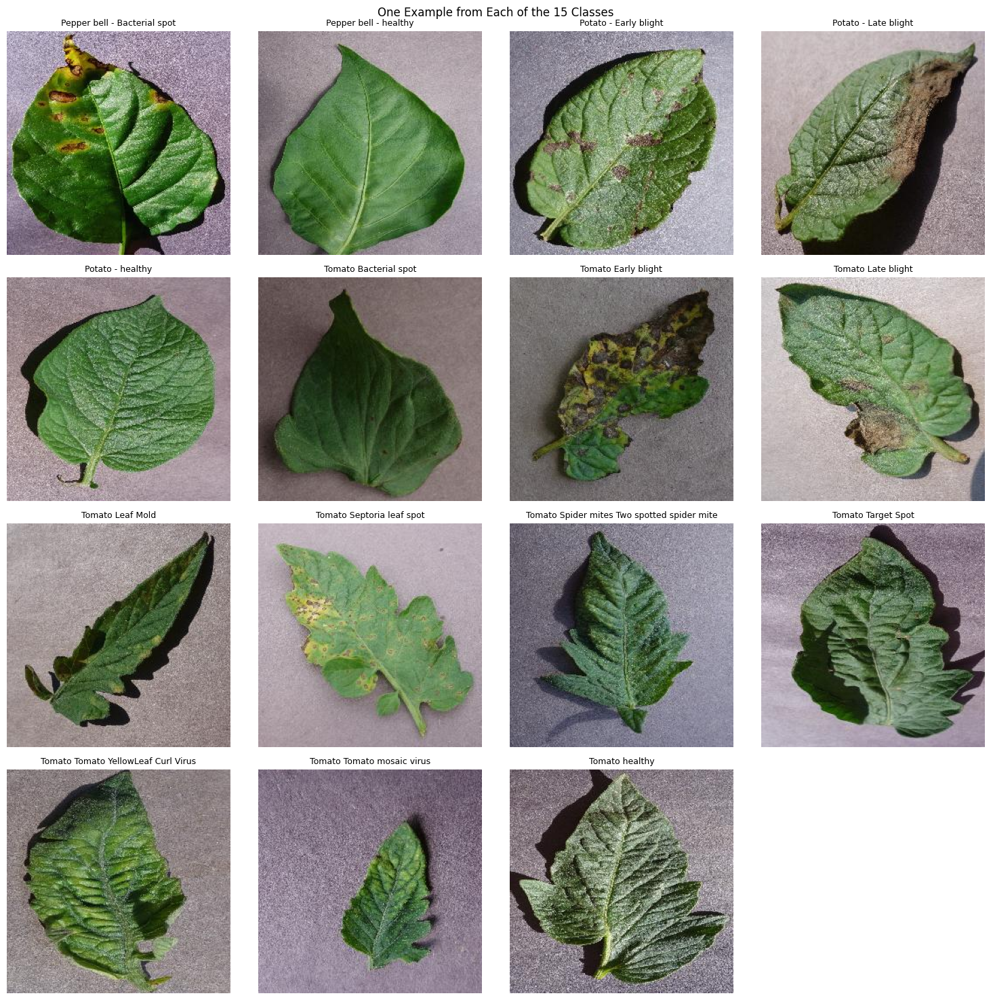

In [9]:
def readable_label(label):
    s = label.replace("___", " - ").replace("__", " ").replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

READABLE_NAMES = [readable_label(x) for x in CLASS_NAMES]
LABEL_TO_INDEX = {name: i for i, name in enumerate(CLASS_NAMES)}

fig = plt.figure(figsize=(15, 15))
for i, cls in enumerate(CLASS_NAMES):
    sample = df[df["class_name"] == cls].sample(1, random_state=SEED+i).iloc[0]
    image = Image.open(sample["filepath"]).convert("RGB")
    ax = plt.subplot(4, 4, i+1)
    ax.imshow(image)
    ax.set_title(readable_label(cls), fontsize=9)
    ax.axis("off")
plt.suptitle("One Example from Each of the 15 Classes")
plt.tight_layout()
plt.show()

In [10]:
sample_sizes = []
for path in df["filepath"].sample(min(500, len(df)), random_state=SEED):
    with Image.open(path) as img:
        sample_sizes.append(img.size)

size_df = pd.DataFrame(sample_sizes, columns=["width", "height"])
display(size_df.describe())
display(size_df.value_counts().head(10).rename("count").to_frame())

,width,height
count,500.0,500.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


,,count
width,height,
256,256,500


### EDA Findings and Class Distribution Analysis

The dataset contains 20,638 leaf images distributed across 15 classes representing
healthy and diseased leaves from pepper, potato and tomato plants. The exploratory
analysis shows that the dataset is imbalanced across the different classes.

The largest class is `Tomato__Tomato_YellowLeaf__Curl_Virus`, containing 3,208
images (15.54% of the dataset), whereas the smallest class is `Potato___healthy`,
with only 152 images (0.74%). This corresponds to a largest-to-smallest class ratio
of approximately 21.11:1. Two relatively small classes are particularly noticeable:
`Potato___healthy` (152 images) and `Tomato__Tomato_mosaic_virus` (373 images).

This imbalance is important because overall classification accuracy alone may not
provide a complete representation of model performance. A model could achieve high
accuracy by performing strongly on the larger classes while producing weaker
predictions for under-represented classes. Therefore, model evaluation will include
macro-averaged precision, recall and F1-score in addition to overall accuracy.
Weighted F1-score and class-specific precision, recall and F1-score will also be
examined.

A stratified train-validation-test split will be used so that the relative
distribution of each class is maintained across the three subsets. The test set
will remain separate from model development and will only be used for the final
evaluation of the selected model.

## Split Dataset into Train, Validation and Test Sets

In [11]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["class_name"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["class_name"], random_state=SEED
)

split_summary = pd.DataFrame({
    "Train": train_df["class_name"].value_counts(),
    "Validation": val_df["class_name"].value_counts(),
    "Test": test_df["class_name"].value_counts()
}).reindex(CLASS_NAMES)

display(split_summary)
print("Train:", len(train_df), f"({len(train_df)/len(df):.2%})")
print("Validation:", len(val_df), f"({len(val_df)/len(df):.2%})")
print("Test:", len(test_df), f"({len(test_df)/len(df):.2%})")

assert set(train_df.filepath).isdisjoint(set(val_df.filepath))
assert set(train_df.filepath).isdisjoint(set(test_df.filepath))
assert set(val_df.filepath).isdisjoint(set(test_df.filepath))
print("Leakage check passed: splits contain distinct files.")

,Train,Validation,Test
class_name,,,
Pepper__bell___Bacterial_spot,698,150,149
Pepper__bell___healthy,1035,222,221
Potato___Early_blight,700,150,150
Potato___Late_blight,700,150,150
Potato___healthy,106,23,23
Tomato_Bacterial_spot,1489,319,319
Tomato_Early_blight,700,150,150
Tomato_Late_blight,1336,286,287
Tomato_Leaf_Mold,666,143,143


Train: 14446 (70.00%)
Validation: 3096 (15.00%)
Test: 3096 (15.00%)
Leakage check passed: splits contain distinct files.


## TensorFlow data pipeline

In [12]:
def make_dataset(frame, shuffle=False):
    paths = frame["filepath"].astype(str).values
    labels = frame["class_name"].map(LABEL_TO_INDEX).astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.io.decode_image(image, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32)
        return image, label

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(min(len(frame), 4000), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

for images, labels in train_ds.take(1):
    print("Images:", images.shape, images.dtype)
    print("Labels:", labels.shape)
    print("Pixel range:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))

I0000 00:00:1790963297.562795      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790963297.571033      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Images: (32, 224, 224, 3) <dtype: 'float32'>
Labels: (32,)
Pixel range: 0.0 254.41839599609375


## Data augmentation

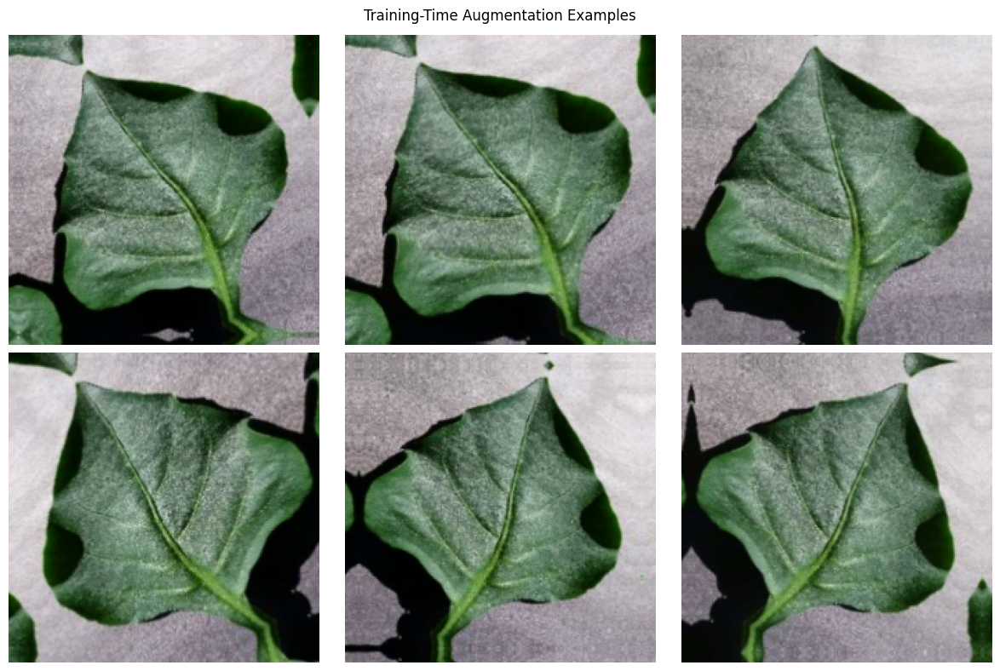

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 8))
    for i in range(6):
        aug = data_augmentation(images[:1], training=True)[0]
        plt.subplot(2, 3, i+1)
        plt.imshow(tf.cast(tf.clip_by_value(aug, 0, 255), tf.uint8))
        plt.axis("off")
    plt.suptitle("Training-Time Augmentation Examples")
    plt.tight_layout()
    plt.show()

## Experiment utilities

Every candidate model is evaluated on the same validation split. We record:
- Validation accuracy
- Macro precision, recall and F1
- Weighted F1
- Best validation loss
- Epochs trained
- Training time
Macro F1 gives equal importance to all 15 classes. Weighted F1 reflects class frequencies. Reporting both is useful because this dataset is imbalanced.

In [14]:
experiment_results = []
trained_models = {}
histories = {}

def callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=4, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
        )
    ]

def predict_dataset(model, dataset):
    probs = model.predict(dataset, verbose=0)
    pred = np.argmax(probs, axis=1)
    true = np.concatenate([y.numpy() for _, y in dataset])
    return true, pred, probs

def validation_metrics(model):
    y_true, y_pred, _ = predict_dataset(model, val_ds)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "val_accuracy": accuracy_score(y_true, y_pred),
        "val_precision_macro": p,
        "val_recall_macro": r,
        "val_f1_macro": f1,
        "val_f1_weighted": weighted_f1
    }

def record(name, model, history, seconds, notes):
    row = {
        "experiment": name,
        **validation_metrics(model),
        "best_val_loss": min(history.history["val_loss"]),
        "epochs_trained": len(history.history["loss"]),
        "training_seconds": seconds,
        "notes": notes
    }
    experiment_results.append(row)
    trained_models[name] = model
    histories[name] = history
    display(pd.DataFrame([row]))
    return row

def plot_history(history, title):
    epochs = range(1, len(history.history["loss"])+1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, history.history["accuracy"], label="Train")
    plt.plot(epochs, history.history["val_accuracy"], label="Validation")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(title + " — Accuracy")
    plt.legend(); plt.grid(alpha=.3); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(epochs, history.history["loss"], label="Train")
    plt.plot(epochs, history.history["val_loss"], label="Validation")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend(); plt.grid(alpha=.3); plt.show()

def train_and_record(name, model, epochs, notes):
    start = time.time()
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs, callbacks=callbacks(), verbose=1
    )
    seconds = time.time() - start
    record(name, model, history, seconds, notes)
    plot_history(history, name)
    return model, history

## Experiment 1 - Baseline CNN

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,367 (49.36 MB)

 Trainable params: 12,940,367 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.5817 - loss: 1.3132 - val_accuracy: 0.7487 - val_loss: 0.7753 - learning_rate: 0.0010
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.7953 - loss: 0.6050 - val_accuracy: 0.8453 - val_loss: 0.4519 - learning_rate: 0.0010
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.8438 - loss: 0.4601 - val_accuracy: 0.8214 - val_loss: 0.5784 - learning_rate: 0.0010
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.8797 - loss: 0.3609 - val_accuracy: 0.8882 - val_loss: 0.3318 - learning_rate: 0.0010
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.8949 - loss: 0.3067 - val_accuracy: 0.8656 - val_loss: 0.4410 - learning_rate: 0.0010
Epoch 6/20
451/452 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9105 - loss: 0.2539
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
452/452 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - accuracy: 0.9131 - los

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
0,Baseline CNN,0.95155,0.94523,0.945205,0.944442,0.951331,0.156896,15,523.646899,3 convolution blocks; Adam; augmentation


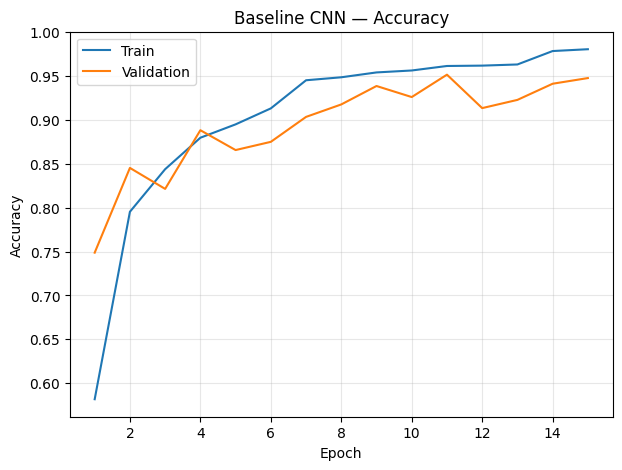

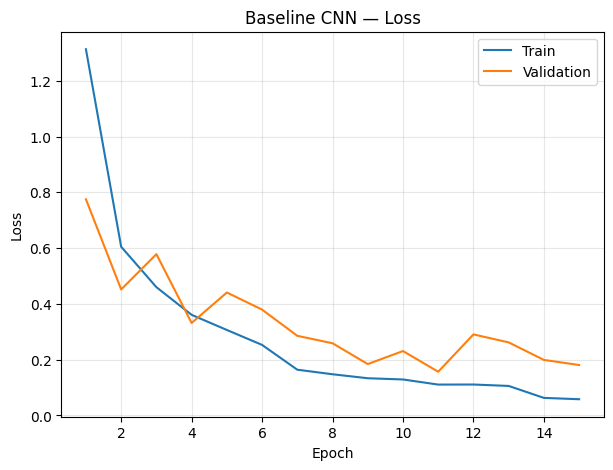

In [15]:
def build_baseline(optimizer=None, augment=True):
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs) if augment else inputs
    x = layers.Rescaling(1./255)(x)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="baseline_cnn")
    model.compile(
        optimizer=optimizer or keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline = build_baseline()
baseline.summary()
baseline, baseline_hist = train_and_record(
    "Baseline CNN", baseline, 20,
    "3 convolution blocks; Adam; augmentation"
)

### Baseline CNN Analysis

The baseline CNN demonstrated strong learning performance on the 15-class PlantVillage
classification problem. Training accuracy increased from approximately 56.84% during
the first epoch to over 95% by epoch 11, while validation accuracy reached 94.61% at
epoch 11.

The learning curves indicate that the model did not improve uniformly throughout
training. In particular, validation accuracy decreased during epochs 6 and 7 while
training performance continued to improve. Validation loss similarly increased,
reaching approximately 0.717 at epoch 7. This suggests temporary overfitting or
instability in generalisation despite continued improvement on the training data.

The ReduceLROnPlateau callback reduced the learning rate from 0.001 to 0.0005 after
validation performance stopped improving. Following this reduction, validation
performance recovered substantially, reaching approximately 94% accuracy by epochs
9–11. The lowest validation loss of approximately 0.167 was obtained at epoch 11.

After epoch 11, training accuracy continued to increase, eventually exceeding 98%,
while validation accuracy fluctuated between approximately 89% and 94%. This widening
and unstable relationship between training and validation performance provides
evidence that further training did not consistently improve generalisation.

Early stopping terminated training at epoch 15 and restored the weights from epoch 11,
which had achieved the best validation loss. Therefore, epoch 11 represents the
selected state of the baseline CNN rather than the final epoch.

Although the baseline demonstrates promising performance, overall accuracy alone is
insufficient because the dataset is substantially imbalanced. Macro-averaged precision,
recall and F1-score are therefore also required to determine whether the model performs
consistently across both majority and minority classes.

## Experiment 2 - Deeper CNN + Batch Normalization + Dropout

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,16

 Total params: 654,639 (2.50 MB)

 Trainable params: 653,231 (2.49 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/25


E0000 00:00:1790963852.081576      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/deeper_cnn_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


452/452 ━━━━━━━━━━━━━━━━━━━━ 157s 319ms/step - accuracy: 0.6604 - loss: 1.0250 - val_accuracy: 0.1589 - val_loss: 7.0171 - learning_rate: 0.0010
Epoch 2/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 147s 313ms/step - accuracy: 0.7897 - loss: 0.6258 - val_accuracy: 0.5759 - val_loss: 2.0518 - learning_rate: 0.0010
Epoch 3/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 145s 312ms/step - accuracy: 0.8454 - loss: 0.4676 - val_accuracy: 0.5462 - val_loss: 2.4989 - learning_rate: 0.0010
Epoch 4/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 146s 312ms/step - accuracy: 0.8666 - loss: 0.3961 - val_accuracy: 0.6663 - val_loss: 1.6902 - learning_rate: 0.0010
Epoch 5/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 147s 312ms/step - accuracy: 0.8946 - loss: 0.3119 - val_accuracy: 0.6663 - val_loss: 1.4749 - learning_rate: 0.0010
Epoch 6/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 145s 312ms/step - accuracy: 0.9038 - loss: 0.2879 - val_accuracy: 0.7910 - val_loss: 0.6703 - learning_rate: 0.0010
Epoch 7/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 146s 311ms/step - accuracy: 0.9177 

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
0,Deeper CNN + Adam + Dropout,0.97739,0.971342,0.977898,0.973762,0.977259,0.089931,20,2931.008222,Deeper architecture; BatchNorm; Dropout; Adam;...


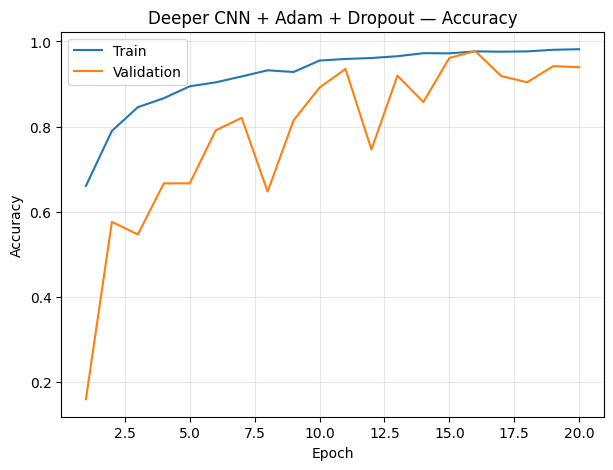

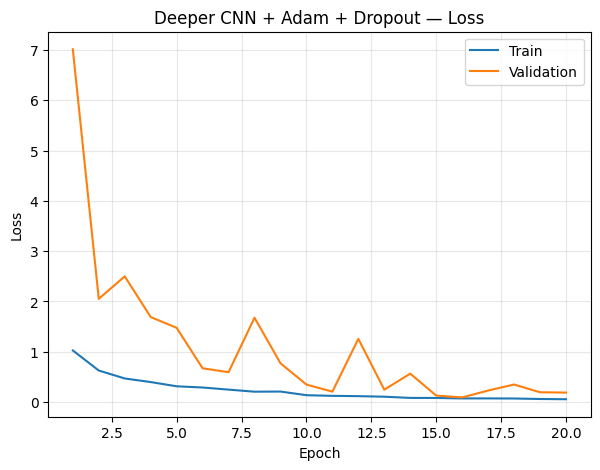

In [16]:
def build_deeper(optimizer=None, dropout=True, augment=True):
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs) if augment else inputs
    x = layers.Rescaling(1./255)(x)

    for filters, rate in [(32,.15),(64,.20),(128,.25)]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        if dropout:
            x = layers.Dropout(rate)(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    if dropout:
        x = layers.Dropout(.40)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="deeper_cnn")
    model.compile(
        optimizer=optimizer or keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

deep_adam = build_deeper()
deep_adam.summary()
deep_adam, deep_adam_hist = train_and_record(
    "Deeper CNN + Adam + Dropout", deep_adam, 25,
    "Deeper architecture; BatchNorm; Dropout; Adam; augmentation"
)

### Experiment 2 Analysis - Deeper CNN with Batch Normalization and Dropout

The deeper CNN achieved a best validation accuracy of approximately 93.02% and a
validation Macro F1-score of 92.57%. The best validation loss was approximately
0.222, obtained at epoch 7. Early stopping subsequently terminated training at
epoch 11 and restored the weights from epoch 7.

Although training accuracy increased consistently and exceeded 96%, validation
performance was considerably less stable. For example, validation accuracy reached
93.02% at epoch 7 before falling sharply to 48.84% at epoch 8 and subsequently
recovering to 87.82% at epoch 9. Validation loss similarly increased from
approximately 0.222 to 3.692 between epochs 7 and 8. This indicates substantial
instability in generalisation despite continued improvement in training performance.

Compared with the simpler baseline CNN, increasing architectural complexity did not
produce a clear improvement. The baseline achieved a higher best validation accuracy
of approximately 94.61% and a lower best validation loss of approximately 0.167.
The deeper architecture also required substantially more training time.

These findings demonstrate that increasing model depth and complexity does not
automatically improve generalisation. The result motivates further controlled
experiments investigating optimisation and regularisation before selecting the final
model.

### Comparison with the Baseline CNN

The deeper CNN did not outperform the simpler baseline architecture. The baseline
achieved a validation accuracy of 94.61% and a Macro F1-score of 94.01%, compared
with 93.02% validation accuracy and 92.57% Macro F1 for the deeper CNN.

The baseline also achieved a lower best validation loss (0.167 compared with 0.222),
indicating stronger validation performance under the experimental configuration.
Furthermore, the deeper architecture required approximately 1,733 seconds of
training, compared with approximately 516 seconds for the baseline, making it over
three times more computationally expensive.

The learning curves also differed considerably. The baseline demonstrated relatively
stable validation behaviour, whereas the deeper model showed substantial fluctuations.
For example, its validation accuracy increased to 93.02% at epoch 7 before falling
to 48.84% at epoch 8. This occurred despite continued improvement in training
accuracy, suggesting unstable generalisation.

The comparison therefore demonstrates that increasing architectural complexity does
not necessarily improve classification performance. Under the configurations tested,
the simpler baseline CNN provided stronger validation performance while requiring
substantially less training time.

The baseline Macro F1-score (94.01%) was relatively close to its Weighted F1-score
(94.60%). This suggests that the strong aggregate performance was not solely driven
by the largest classes. Nevertheless, class-specific metrics are required before
drawing conclusions about performance on highly under-represented classes.

## Experimentation and Comparative Analysis

### Optimizer experiment: Adam vs SGD

Epoch 1/25


E0000 00:00:1790966798.170461      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/deeper_cnn_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


452/452 ━━━━━━━━━━━━━━━━━━━━ 155s 312ms/step - accuracy: 0.6351 - loss: 1.1133 - val_accuracy: 0.1625 - val_loss: 10.0718 - learning_rate: 0.0100
Epoch 2/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 145s 310ms/step - accuracy: 0.7835 - loss: 0.6507 - val_accuracy: 0.7306 - val_loss: 0.8190 - learning_rate: 0.0100
Epoch 3/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 145s 310ms/step - accuracy: 0.8298 - loss: 0.5090 - val_accuracy: 0.5672 - val_loss: 1.5884 - learning_rate: 0.0100
Epoch 4/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8479 - loss: 0.4561
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
452/452 ━━━━━━━━━━━━━━━━━━━━ 144s 310ms/step - accuracy: 0.8594 - loss: 0.4248 - val_accuracy: 0.7003 - val_loss: 1.2831 - learning_rate: 0.0100
Epoch 5/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 144s 310ms/step - accuracy: 0.8993 - loss: 0.3059 - val_accuracy: 0.7703 - val_loss: 0.8342 - learning_rate: 0.0050
Epoch 6/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9038 - los

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
0,Deeper CNN + SGD + Dropout,0.73062,0.795827,0.710693,0.714538,0.721264,0.819044,6,877.16736,Same deeper model; optimizer changed to SGD wi...


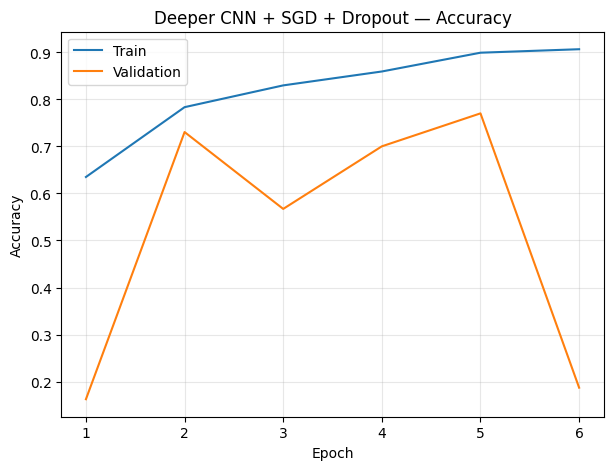

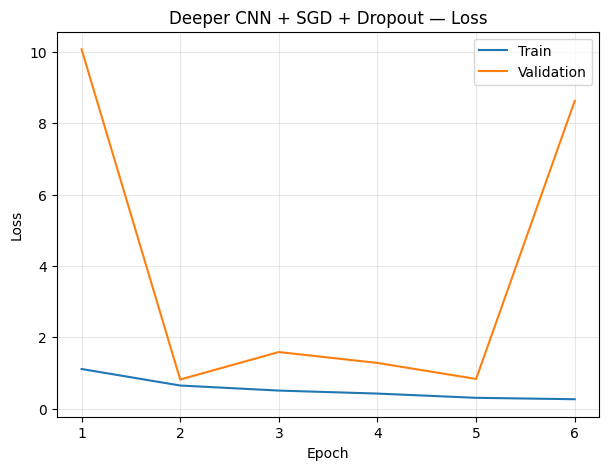

In [17]:
deep_sgd = build_deeper(
    optimizer=keras.optimizers.SGD(learning_rate=.01, momentum=.9)
)
deep_sgd, deep_sgd_hist = train_and_record(
    "Deeper CNN + SGD + Dropout", deep_sgd, 25,
    "Same deeper model; optimizer changed to SGD with momentum 0.9"
)

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
1,Deeper CNN + Adam + Dropout,0.97739,0.971342,0.977898,0.973762,0.977259,0.089931,20,2931.008222,Deeper architecture; BatchNorm; Dropout; Adam;...
2,Deeper CNN + SGD + Dropout,0.73062,0.795827,0.710693,0.714538,0.721264,0.819044,6,877.167360,Same deeper model; optimizer changed to SGD wi...


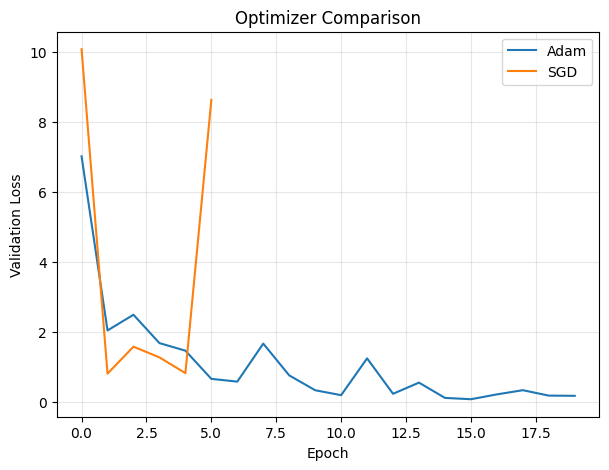

In [18]:
opt_df = pd.DataFrame(experiment_results)
opt_df = opt_df[opt_df.experiment.isin([
    "Deeper CNN + Adam + Dropout",
    "Deeper CNN + SGD + Dropout"
])]
display(opt_df)

plt.figure(figsize=(7,5))
plt.plot(deep_adam_hist.history["val_loss"], label="Adam")
plt.plot(deep_sgd_hist.history["val_loss"], label="SGD")
plt.xlabel("Epoch"); plt.ylabel("Validation Loss")
plt.title("Optimizer Comparison")
plt.legend(); plt.grid(alpha=.3); plt.show()

### Dropout ablation

Epoch 1/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 134s 275ms/step - accuracy: 0.7262 - loss: 0.8263 - val_accuracy: 0.2755 - val_loss: 3.9224 - learning_rate: 0.0010
Epoch 2/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 128s 274ms/step - accuracy: 0.8496 - loss: 0.4481 - val_accuracy: 0.5607 - val_loss: 1.6255 - learning_rate: 0.0010
Epoch 3/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 128s 274ms/step - accuracy: 0.8897 - loss: 0.3232 - val_accuracy: 0.4512 - val_loss: 2.7632 - learning_rate: 0.0010
Epoch 4/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 128s 274ms/step - accuracy: 0.9086 - loss: 0.2733 - val_accuracy: 0.6954 - val_loss: 1.0432 - learning_rate: 0.0010
Epoch 5/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 128s 274ms/step - accuracy: 0.9250 - loss: 0.2185 - val_accuracy: 0.8236 - val_loss: 0.5929 - learning_rate: 0.0010
Epoch 6/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 128s 273ms/step - accuracy: 0.9358 - loss: 0.1918 - val_accuracy: 0.7297 - val_loss: 1.3465 - learning_rate: 0.0010
Epoch 7/25
452/452 ━━━━━━━━━━━━━━━━━━━━ 128s 273ms/step - accura

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
0,Deeper CNN + Adam + No Dropout,0.980297,0.97998,0.981335,0.980281,0.980366,0.059322,25,3211.50743,"Dropout removed; architecture, BatchNorm, Adam..."


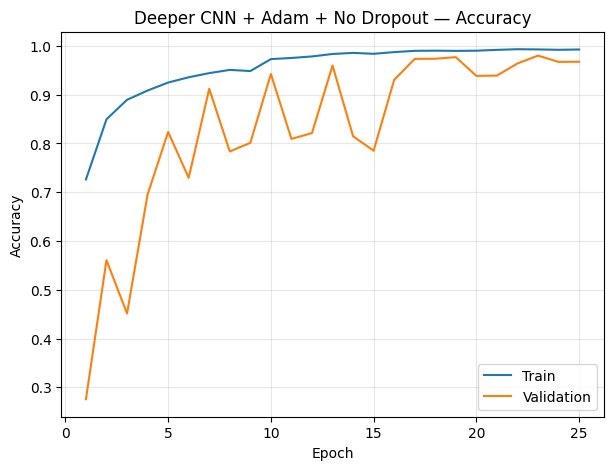

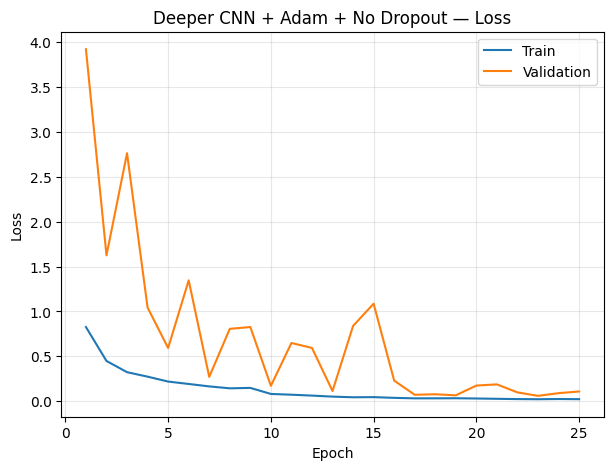

In [19]:
deep_no_dropout = build_deeper(
    optimizer=keras.optimizers.Adam(1e-3),
    dropout=False
)
deep_no_dropout, no_dropout_hist = train_and_record(
    "Deeper CNN + Adam + No Dropout", deep_no_dropout, 25,
    "Dropout removed; architecture, BatchNorm, Adam and augmentation retained"
)

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
1,Deeper CNN + Adam + Dropout,0.977390,0.971342,0.977898,0.973762,0.977259,0.089931,20,2931.008222,Deeper architecture; BatchNorm; Dropout; Adam;...
3,Deeper CNN + Adam + No Dropout,0.980297,0.979980,0.981335,0.980281,0.980366,0.059322,25,3211.507430,"Dropout removed; architecture, BatchNorm, Adam..."


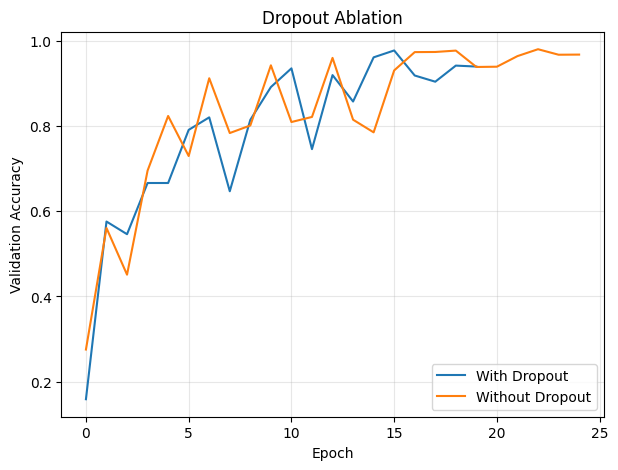

In [20]:
drop_df = pd.DataFrame(experiment_results)
drop_df = drop_df[drop_df.experiment.isin([
    "Deeper CNN + Adam + Dropout",
    "Deeper CNN + Adam + No Dropout"
])]
display(drop_df)

plt.figure(figsize=(7,5))
plt.plot(deep_adam_hist.history["val_accuracy"], label="With Dropout")
plt.plot(no_dropout_hist.history["val_accuracy"], label="Without Dropout")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.title("Dropout Ablation")
plt.legend(); plt.grid(alpha=.3); plt.show()

### Dropout Ablation Analysis

The Dropout ablation produced a substantial improvement in validation performance.
When Dropout was removed from the deeper CNN, validation accuracy increased from
93.02% to 96.83%, while Macro F1 increased from 92.57% to 96.88%. The best
validation loss also decreased considerably, from approximately 0.222 to 0.091.

These results indicate that Dropout did not improve generalisation for this
particular architecture and experimental configuration. One possible interpretation
is that the combination of data augmentation, Batch Normalization and Dropout
provided more regularisation than was required. Removing Dropout may therefore have
allowed the model to learn more useful discriminative representations from the
training data.

However, the validation curves remained highly unstable. Validation accuracy
fluctuated substantially between epochs, despite training accuracy increasing
consistently towards 99%. For example, validation accuracy reached 96.64% at epoch
12, decreased to 73.68% at epoch 14, and subsequently recovered to 96.83% at epoch
16. Similar fluctuations were observed in validation loss.

The EarlyStopping callback restored the weights from epoch 16, which achieved the
lowest validation loss of approximately 0.091. At this checkpoint, the difference
between training and validation accuracy was relatively small, despite the high
training accuracy.

Therefore, the experiment provides evidence that removing Dropout improved the best
validation performance under the tested conditions, but it did not eliminate
validation instability. This demonstrates the importance of empirically evaluating
regularisation techniques rather than assuming that additional regularisation will
always improve model generalisation.

### Data augmentation ablation

Epoch 1/20
  3/452 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.0972 - loss: 3.2301

I0000 00:00:1790970933.459346      72 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


452/452 ━━━━━━━━━━━━━━━━━━━━ 48s 75ms/step - accuracy: 0.6704 - loss: 1.0233 - val_accuracy: 0.7829 - val_loss: 0.6237 - learning_rate: 0.0010
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 33s 62ms/step - accuracy: 0.8557 - loss: 0.4294 - val_accuracy: 0.8349 - val_loss: 0.4916 - learning_rate: 0.0010
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 32s 61ms/step - accuracy: 0.9057 - loss: 0.2773 - val_accuracy: 0.8026 - val_loss: 0.6747 - learning_rate: 0.0010
Epoch 4/20
451/452 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9282 - loss: 0.2055
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
452/452 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9389 - loss: 0.1797 - val_accuracy: 0.8566 - val_loss: 0.4916 - learning_rate: 0.0010
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.9806 - loss: 0.0615 - val_accuracy: 0.9121 - val_loss: 0.3175 - learning_rate: 5.0000e-04
Epoch 6/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.9916 - loss: 0.03

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
0,Baseline CNN — No Augmentation,0.912145,0.90849,0.902912,0.904057,0.911204,0.317476,9,309.513736,Baseline architecture; Adam; augmentation removed


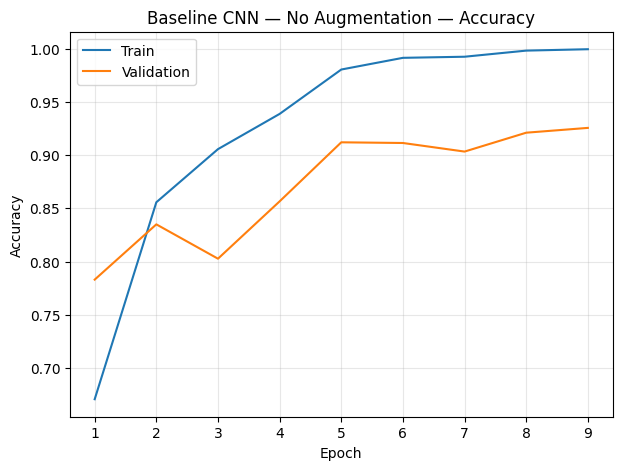

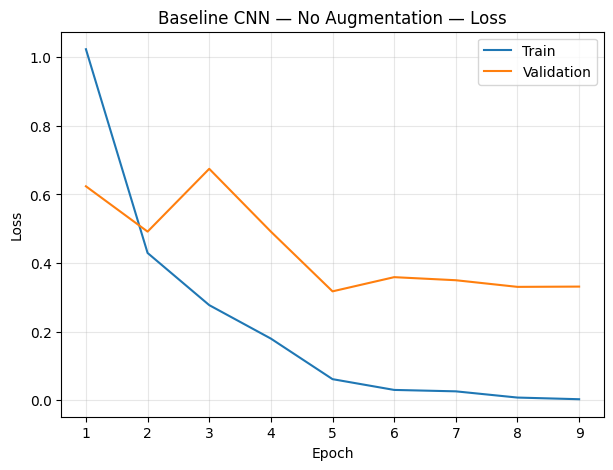

In [21]:
baseline_no_aug = build_baseline(
    optimizer=keras.optimizers.Adam(1e-3),
    augment=False
)
baseline_no_aug, no_aug_hist = train_and_record(
    "Baseline CNN — No Augmentation", baseline_no_aug, 20,
    "Baseline architecture; Adam; augmentation removed"
)

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
0,Baseline CNN,0.951550,0.94523,0.945205,0.944442,0.951331,0.156896,15,523.646899,3 convolution blocks; Adam; augmentation
4,Baseline CNN — No Augmentation,0.912145,0.90849,0.902912,0.904057,0.911204,0.317476,9,309.513736,Baseline architecture; Adam; augmentation removed


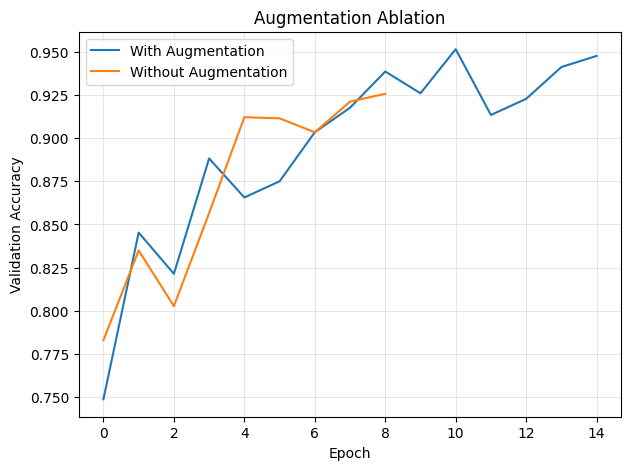

In [22]:
aug_df = pd.DataFrame(experiment_results)
aug_df = aug_df[aug_df.experiment.isin([
    "Baseline CNN", "Baseline CNN — No Augmentation"
])]
display(aug_df)

plt.figure(figsize=(7,5))
plt.plot(baseline_hist.history["val_accuracy"], label="With Augmentation")
plt.plot(no_aug_hist.history["val_accuracy"], label="Without Augmentation")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.title("Augmentation Ablation")
plt.legend(); plt.grid(alpha=.3); plt.show()

### Data Augmentation Ablation Analysis

The data augmentation ablation demonstrated that augmentation improved the
generalisation performance of the baseline CNN. With augmentation, the model
achieved a validation accuracy of 94.61% and a Macro F1-score of 94.01%.
When augmentation was removed, validation accuracy decreased to 91.38% and
Macro F1 decreased to 89.75%.

The difference between training and validation performance was also substantially
more pronounced without augmentation. Training accuracy increased rapidly and
eventually reached 100%, with training loss approaching zero. However, validation
accuracy remained around 91% and the best validation loss was approximately 0.381.
This indicates that the non-augmented model fitted the training images extremely
closely without achieving equivalent generalisation to unseen validation images.

In comparison, the augmented baseline achieved a considerably lower best validation
loss of approximately 0.167. The augmented model also achieved a smaller difference
between Macro F1 (94.01%) and Weighted F1 (94.60%) than the non-augmented model,
whose Macro and Weighted F1-scores were 89.75% and 91.32%, respectively. Given the
class imbalance identified during exploratory analysis, this provides additional
motivation for considering macro-averaged metrics alongside overall accuracy.

The experiment therefore provides evidence that the selected image augmentation
strategy improved validation generalisation under the tested configuration. Although
augmentation slightly increased training time, the improvement in validation
accuracy, Macro F1 and validation loss justified retaining augmentation in subsequent
model development.

## Transfer Learning - MobileNetV2

MobileNetV2 uses features pretrained on ImageNet. This tests whether pretrained general visual representations transfer effectively to plant disease classification.

In [23]:
def build_mobilenet():
    base = keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE,3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE,3))
    x = data_augmentation(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(.30)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base

mobile, mobile_base = build_mobilenet()
mobile.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Feature extraction

Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 44s 75ms/step - accuracy: 0.7048 - loss: 0.9366 - val_accuracy: 0.8269 - val_loss: 0.5449 - learning_rate: 0.0010
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - accuracy: 0.8342 - loss: 0.5097 - val_accuracy: 0.8737 - val_loss: 0.3997 - learning_rate: 0.0010
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.8550 - loss: 0.4397 - val_accuracy: 0.8750 - val_loss: 0.3930 - learning_rate: 0.0010
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - accuracy: 0.8730 - loss: 0.3926 - val_accuracy: 0.8905 - val_loss: 0.3463 - learning_rate: 0.0010
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.8715 - loss: 0.3826 - val_accuracy: 0.8837 - val_loss: 0.3519 - learning_rate: 0.0010
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 36s 67ms/step - accuracy: 0.8822 - loss: 0.3535 - val_accuracy: 0.8892 - val_loss: 0.3376 - learning_rate: 0.0010
Epoch 7/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.8775 - l

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
0,MobileNetV2 — Feature Extraction,0.911176,0.915377,0.900365,0.90454,0.90998,0.278155,14,507.301995,ImageNet MobileNetV2 frozen; classification he...


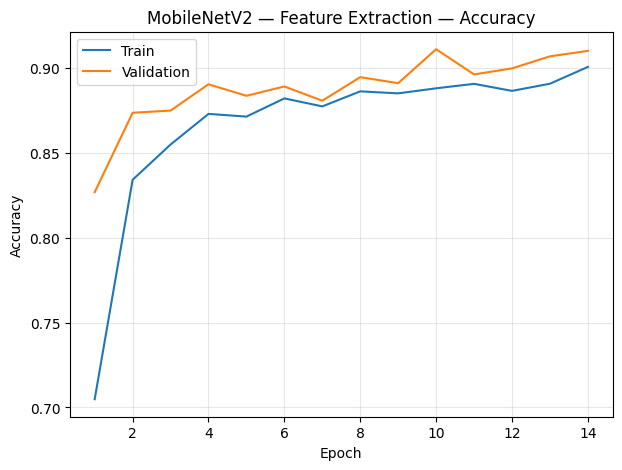

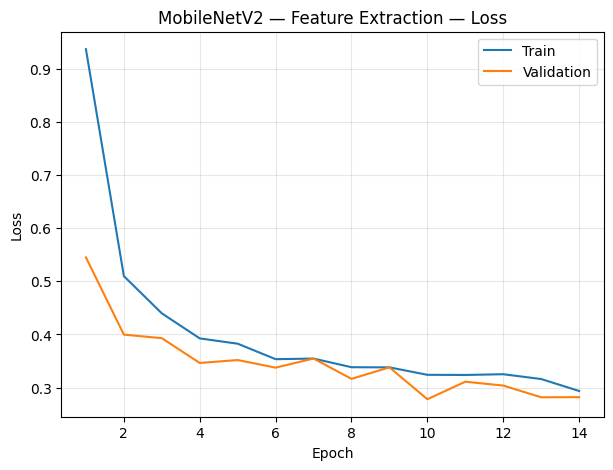

In [24]:
mobile, mobile_hist = train_and_record(
    "MobileNetV2 — Feature Extraction", mobile, 15,
    "ImageNet MobileNetV2 frozen; classification head trained"
)

### Fine-tuning

In [25]:
mobile_base.trainable = True

for layer in mobile_base.layers[:-30]:
    layer.trainable = False

for layer in mobile_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

mobile.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Trainable MobileNetV2 base layers:",
      sum(layer.trainable for layer in mobile_base.layers))

Trainable MobileNetV2 base layers: 19


Epoch 1/12
452/452 ━━━━━━━━━━━━━━━━━━━━ 46s 79ms/step - accuracy: 0.9011 - loss: 0.2914 - val_accuracy: 0.9134 - val_loss: 0.2668 - learning_rate: 1.0000e-05
Epoch 2/12
452/452 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.9149 - loss: 0.2435 - val_accuracy: 0.9205 - val_loss: 0.2454 - learning_rate: 1.0000e-05
Epoch 3/12
452/452 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.9279 - loss: 0.2104 - val_accuracy: 0.9125 - val_loss: 0.2578 - learning_rate: 1.0000e-05
Epoch 4/12
452/452 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.9329 - loss: 0.1941 - val_accuracy: 0.9254 - val_loss: 0.2191 - learning_rate: 1.0000e-05
Epoch 5/12
452/452 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.9385 - loss: 0.1736 - val_accuracy: 0.9409 - val_loss: 0.1822 - learning_rate: 1.0000e-05
Epoch 6/12
452/452 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.9457 - loss: 0.1600 - val_accuracy: 0.9474 - val_loss: 0.1700 - learning_rate: 1.0000e-05
Epoch 7/12
452/452 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/ste

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
0,MobileNetV2 — Fine-Tuned,0.95478,0.953107,0.94974,0.949967,0.954689,0.138208,12,477.774954,Last 30 base layers eligible for fine-tuning; ...


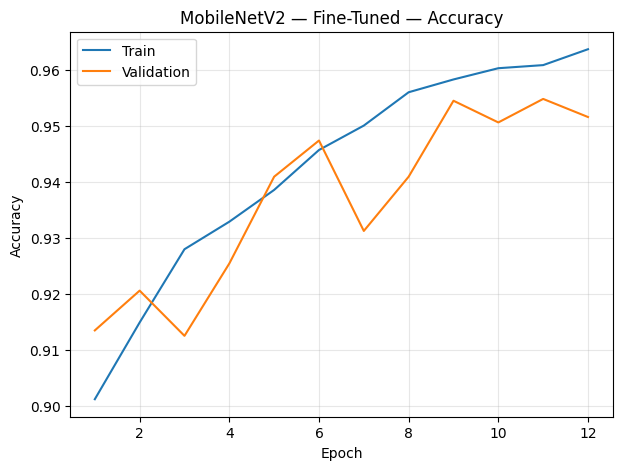

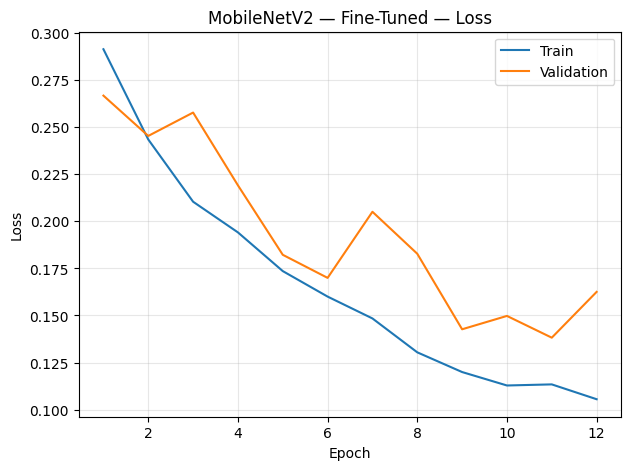

In [26]:
start = time.time()
mobile_ft_hist = mobile.fit(
    train_ds, validation_data=val_ds,
    epochs=12, callbacks=callbacks(), verbose=1
)
record(
    "MobileNetV2 — Fine-Tuned", mobile, mobile_ft_hist,
    time.time()-start,
    "Last 30 base layers eligible for fine-tuning; BatchNorm frozen; LR=1e-5"
)
plot_history(mobile_ft_hist, "MobileNetV2 — Fine-Tuned")

### Transfer Learning and Fine-Tuning Analysis

The transfer-learning experiment was conducted in two stages. Initially, the
ImageNet-pretrained MobileNetV2 convolutional base was frozen and only the newly
added classification layers were trained. This feature-extraction configuration
achieved a validation accuracy of 91.12% and a Macro F1-score of 90.66%, with a
best validation loss of approximately 0.269.

Although the frozen model demonstrated relatively stable learning, its performance
was lower than the strongest custom CNN models. This suggests that generic ImageNet
features were useful for the PlantVillage classification task but were not fully
adapted to the visual characteristics required for distinguishing the 15 plant
health and disease classes.

A second stage therefore fine-tuned the final portion of MobileNetV2. Most of the
pretrained network remained frozen, Batch Normalization layers were kept frozen,
and a substantially smaller learning rate of 1e-5 was used to reduce the risk of
disrupting useful pretrained representations.

Fine-tuning produced a considerable improvement. Validation accuracy increased from
91.12% to 95.99%, while Macro F1 increased from 90.66% to 95.77%. The best
validation loss decreased from approximately 0.269 to 0.137.

The fine-tuned model also demonstrated relatively stable training and validation
curves. At the final epoch, training and validation accuracy were approximately
96.48% and 95.99%, respectively, indicating a comparatively small generalisation
gap.

These findings demonstrate the importance of domain adaptation within transfer
learning. While frozen ImageNet features provided a useful starting representation,
allowing a limited number of higher-level MobileNetV2 layers to adapt to the plant
leaf images substantially improved classification performance.

## Complete comparative analysis

In [27]:
results_df = pd.DataFrame(experiment_results).sort_values(
    "val_f1_macro", ascending=False
).reset_index(drop=True)

display(results_df[[
    "experiment","val_accuracy","val_precision_macro","val_recall_macro",
    "val_f1_macro","val_f1_weighted","best_val_loss",
    "epochs_trained","training_seconds","notes"
]].style.format({
    "val_accuracy":"{:.4f}",
    "val_precision_macro":"{:.4f}",
    "val_recall_macro":"{:.4f}",
    "val_f1_macro":"{:.4f}",
    "val_f1_weighted":"{:.4f}",
    "best_val_loss":"{:.4f}",
    "training_seconds":"{:.1f}"
}))

,experiment,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,best_val_loss,epochs_trained,training_seconds,notes
0,Deeper CNN + Adam + No Dropout,0.9803,0.9800,0.9813,0.9803,0.9804,0.0593,25,3211.5,"Dropout removed; architecture, BatchNorm, Adam and augmentation retained"
1,Deeper CNN + Adam + Dropout,0.9774,0.9713,0.9779,0.9738,0.9773,0.0899,20,2931.0,Deeper architecture; BatchNorm; Dropout; Adam; augmentation
2,MobileNetV2 — Fine-Tuned,0.9548,0.9531,0.9497,0.9500,0.9547,0.1382,12,477.8,Last 30 base layers eligible for fine-tuning; BatchNorm frozen; LR=1e-5
3,Baseline CNN,0.9516,0.9452,0.9452,0.9444,0.9513,0.1569,15,523.6,3 convolution blocks; Adam; augmentation
4,MobileNetV2 — Feature Extraction,0.9112,0.9154,0.9004,0.9045,0.9100,0.2782,14,507.3,ImageNet MobileNetV2 frozen; classification head trained
5,Baseline CNN — No Augmentation,0.9121,0.9085,0.9029,0.9041,0.9112,0.3175,9,309.5,Baseline architecture; Adam; augmentation removed
6,Deeper CNN + SGD + Dropout,0.7306,0.7958,0.7107,0.7145,0.7213,0.8190,6,877.2,Same deeper model; optimizer changed to SGD with momentum 0.9


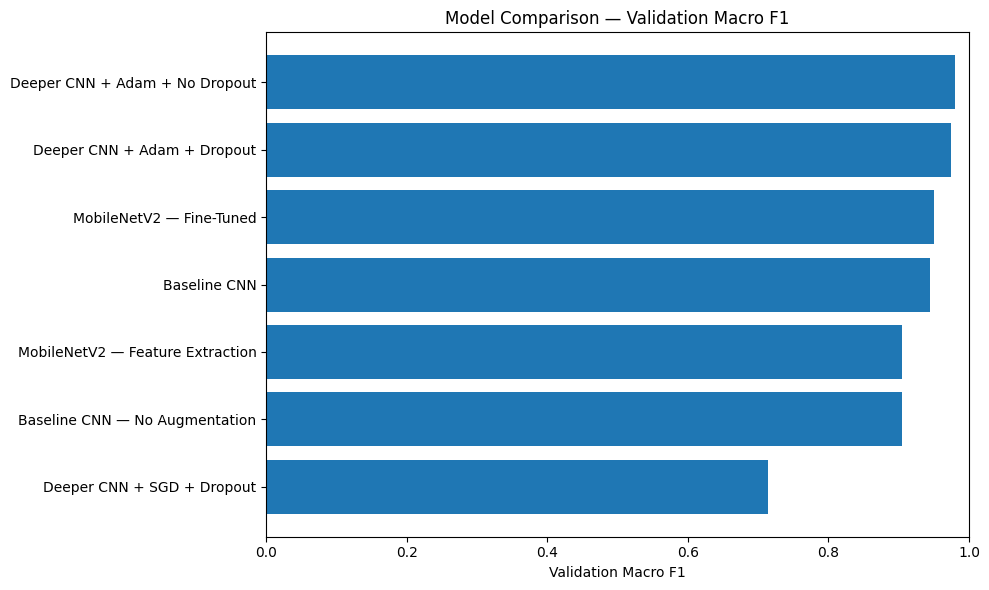

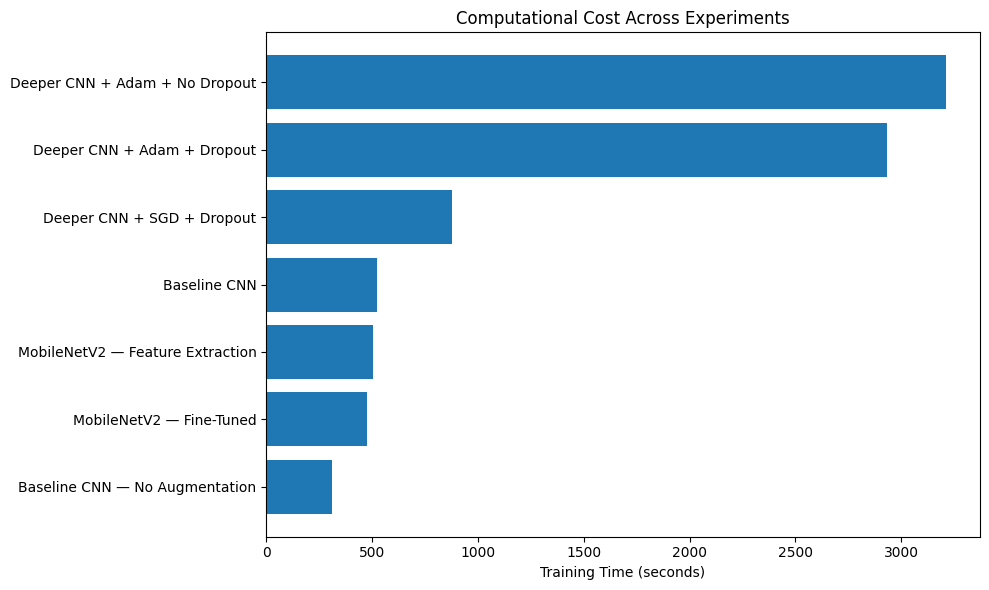

In [28]:
plt.figure(figsize=(10,6))
p = results_df.sort_values("val_f1_macro")
plt.barh(p["experiment"], p["val_f1_macro"])
plt.xlabel("Validation Macro F1")
plt.xlim(0,1)
plt.title("Model Comparison — Validation Macro F1")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,6))
p = results_df.sort_values("training_seconds")
plt.barh(p["experiment"], p["training_seconds"])
plt.xlabel("Training Time (seconds)")
plt.title("Computational Cost Across Experiments")
plt.tight_layout(); plt.show()

### Overall Experimental Comparison and Model Selection

Seven model configurations were evaluated using the same validation dataset. The
experiments investigated architecture complexity, optimizer choice, Dropout, data
augmentation and transfer learning.

The strongest validation performance was obtained by the deeper CNN trained with
Adam and without Dropout. This model achieved a validation accuracy of 96.83%,
Macro F1-score of 96.88% and best validation loss of approximately 0.091. It
therefore outperformed the baseline CNN, the Dropout-based deeper CNN, the SGD
configuration and both MobileNetV2 stages according to the predefined validation
Macro F1 selection criterion.

The experiments demonstrated that increased architectural complexity alone did not
guarantee improved performance. Adding depth, Batch Normalization and Dropout
initially reduced Macro F1 from 94.01% for the baseline to 92.57%. However, the
Dropout ablation subsequently showed that removing Dropout increased Macro F1 to
96.88%, producing the strongest custom CNN configuration.

Optimizer choice also affected performance. Under the tested configurations, Adam
outperformed SGD, while the augmentation ablation demonstrated that removing image
augmentation reduced Macro F1 from 94.01% to 89.75%. This provided evidence that
augmentation contributed meaningfully to generalisation.

Transfer learning produced a further important finding. Frozen MobileNetV2 feature
extraction achieved a Macro F1-score of 90.66%, but fine-tuning part of the
pretrained network increased this to 95.77%. This demonstrates that adapting
higher-level pretrained features to the plant-leaf domain was substantially more
effective than using the frozen ImageNet representation alone.

Although the deeper CNN without Dropout achieved the highest validation Macro F1,
it also required the greatest training time and displayed substantial fluctuations
in validation performance between epochs. In contrast, fine-tuned MobileNetV2
provided competitive performance with smoother learning behaviour and lower
computational cost. This represents an important trade-off between maximum observed
validation performance, computational efficiency and training stability.

Because the dataset is imbalanced, Macro F1 was selected as the primary model
selection metric. Based on the predefined validation criterion, the Deeper CNN +
Adam + No Dropout configuration was selected for final evaluation. The independent
test set had not been used during model development or model selection.

## Final model selection

In [29]:
best_name = results_df.iloc[0]["experiment"]
final_model = trained_models[best_name]

print("Selected model:", best_name)
print(f"Validation Macro F1: {results_df.iloc[0]['val_f1_macro']:.4f}")
print("Selection used validation performance only; test data remains untouched.")

Selected model: Deeper CNN + Adam + No Dropout
Validation Macro F1: 0.9803
Selection used validation performance only; test data remains untouched.


## Final evaluation on untouched test set

In [30]:
y_test, y_pred, y_prob = predict_dataset(final_model, test_ds)

acc = accuracy_score(y_test, y_pred)
p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)
p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted", zero_division=0
)

print("Final model:", best_name)
print(f"Test Accuracy           : {acc:.4f}")
print(f"Test Macro Precision    : {p_macro:.4f}")
print(f"Test Macro Recall       : {r_macro:.4f}")
print(f"Test Macro F1           : {f_macro:.4f}")
print(f"Test Weighted F1        : {f_weight:.4f}")

Final model: Deeper CNN + Adam + No Dropout
Test Accuracy           : 0.9761
Test Macro Precision    : 0.9762
Test Macro Recall       : 0.9768
Test Macro F1           : 0.9761
Test Weighted F1        : 0.9761


In [31]:
report = classification_report(
    y_test, y_pred,
    target_names=READABLE_NAMES,
    digits=4, zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report).T
display(report_df)

,precision,recall,f1-score,support
Pepper bell - Bacterial spot,0.986207,0.959732,0.972789,149.000000
Pepper bell - healthy,0.977679,0.990950,0.984270,221.000000
Potato - Early blight,0.980392,1.000000,0.990099,150.000000
Potato - Late blight,0.903030,0.993333,0.946032,150.000000
Potato - healthy,1.000000,1.000000,1.000000,23.000000
Tomato Bacterial spot,0.963526,0.993730,0.978395,319.000000
Tomato Early blight,0.971831,0.920000,0.945205,150.000000
Tomato Late blight,0.975265,0.961672,0.968421,287.000000
Tomato Leaf Mold,1.000000,0.951049,0.974910,143.000000
Tomato Septoria leaf spot,0.988806,0.996241,0.992509,266.000000


### Confusion matrix

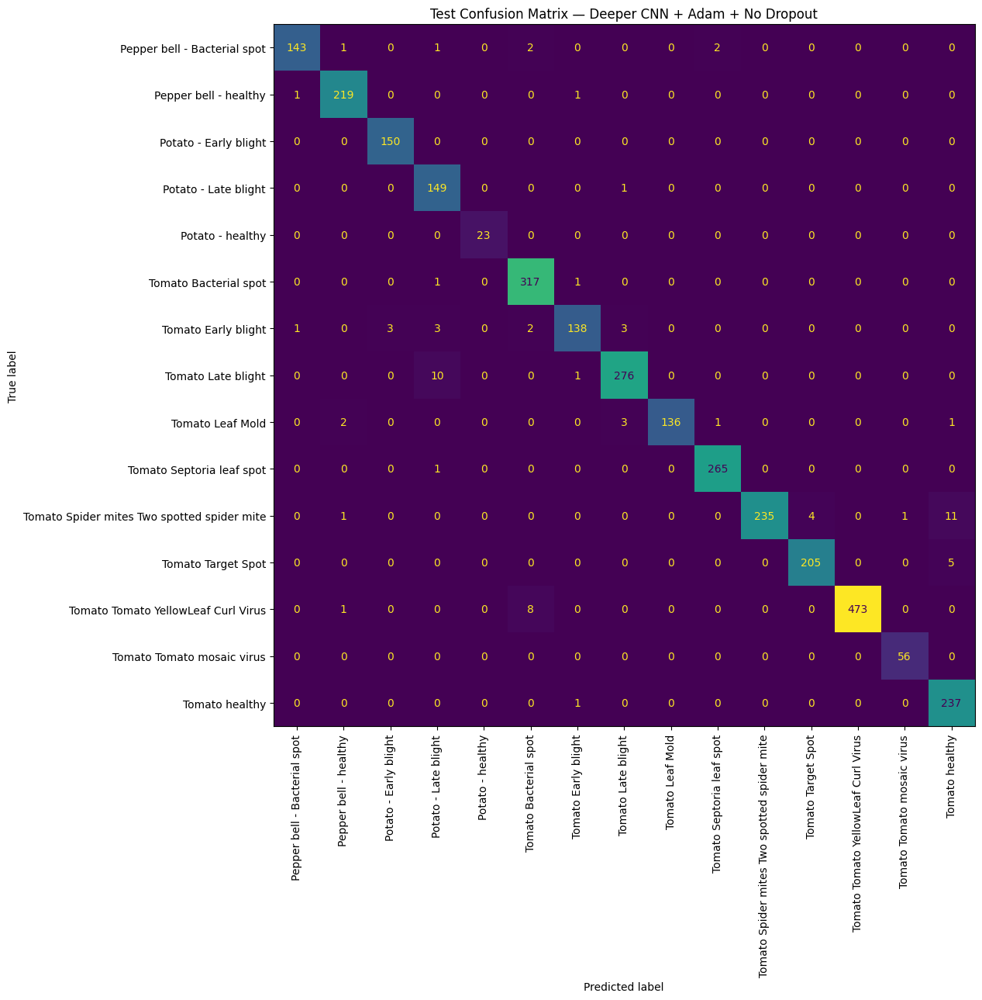

In [32]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(15,13))
disp = ConfusionMatrixDisplay(cm, display_labels=READABLE_NAMES)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title(f"Test Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

### Normalized confusion matrix

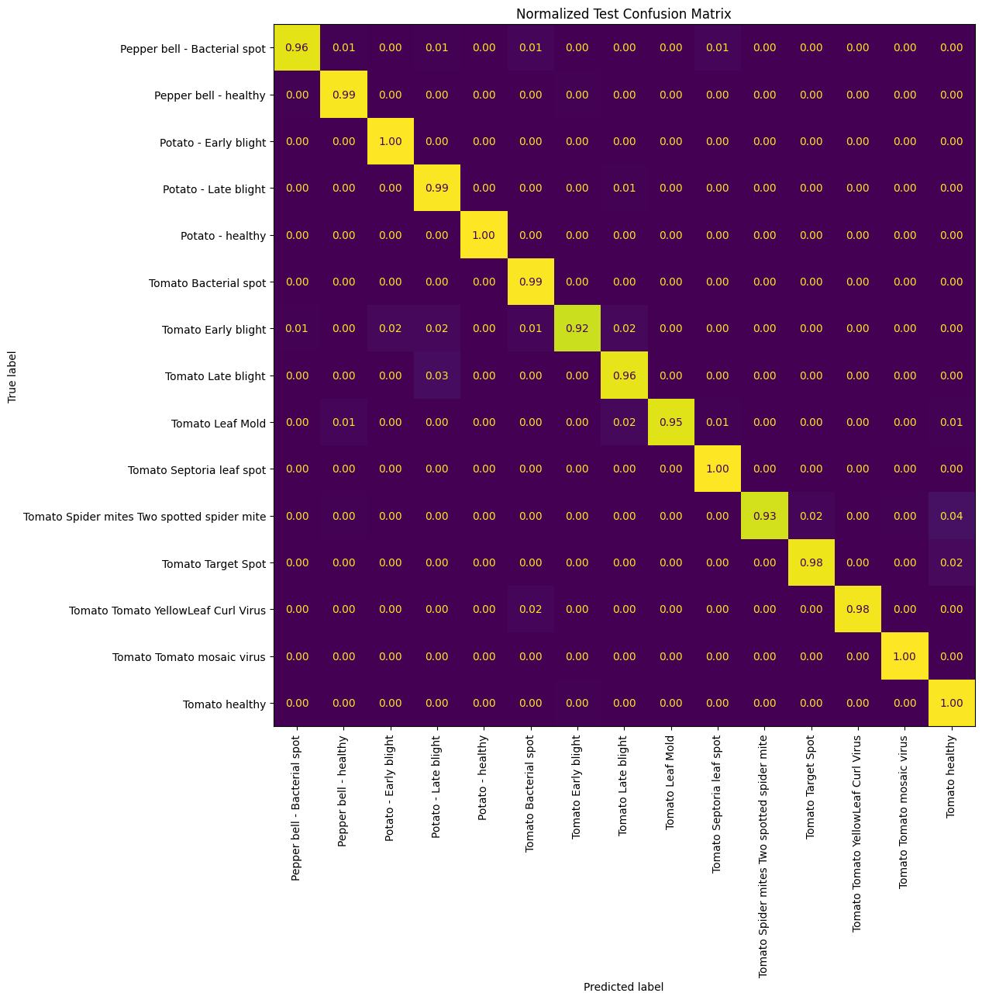

In [33]:
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, where=row_sums!=0)

fig, ax = plt.subplots(figsize=(15,13))
disp = ConfusionMatrixDisplay(cm_norm, display_labels=READABLE_NAMES)
disp.plot(ax=ax, xticks_rotation=90, values_format=".2f", colorbar=False)
plt.title("Normalized Test Confusion Matrix")
plt.tight_layout()
plt.show()

### Per-class performance

,Class,Precision,Recall,F1,Support
6,Tomato Early blight,0.9718,0.9200,0.9452,150
3,Potato - Late blight,0.9030,0.9933,0.9460,150
14,Tomato healthy,0.9331,0.9958,0.9634,238
10,Tomato Spider mites Two spotted spider mite,1.0000,0.9325,0.9651,252
7,Tomato Late blight,0.9753,0.9617,0.9684,287
0,Pepper bell - Bacterial spot,0.9862,0.9597,0.9728,149
8,Tomato Leaf Mold,1.0000,0.9510,0.9749,143
5,Tomato Bacterial spot,0.9635,0.9937,0.9784,319
11,Tomato Target Spot,0.9809,0.9762,0.9785,210
1,Pepper bell - healthy,0.9777,0.9910,0.9843,221


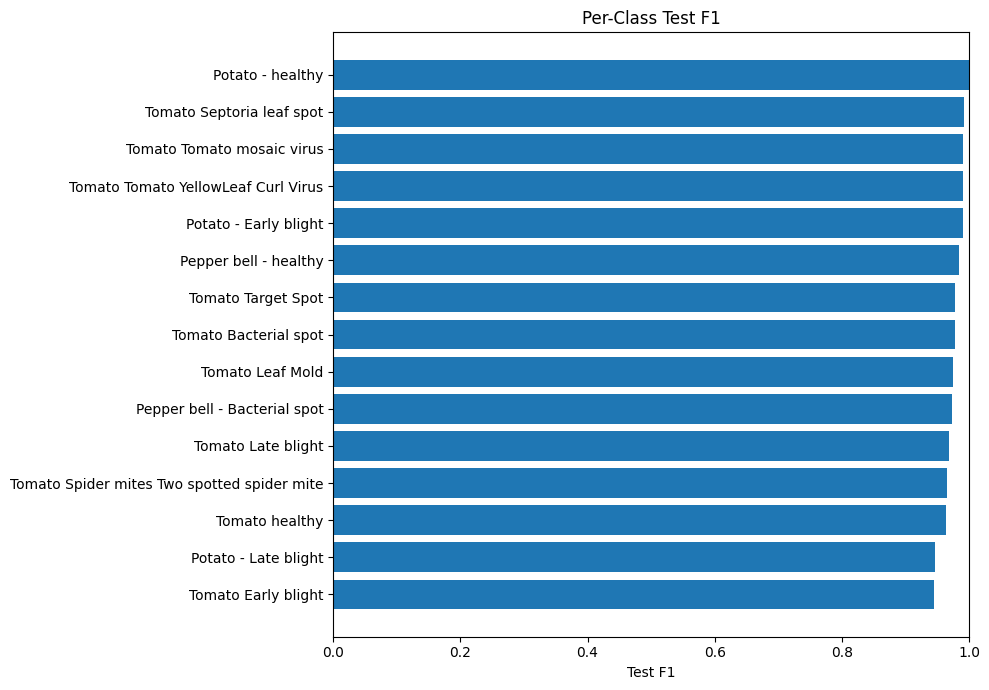

In [34]:
prec, rec, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

per_class = pd.DataFrame({
    "Class": READABLE_NAMES,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "Support": support
}).sort_values("F1")

display(per_class.style.format({
    "Precision":"{:.4f}", "Recall":"{:.4f}", "F1":"{:.4f}"
}))

plt.figure(figsize=(10,7))
plt.barh(per_class["Class"], per_class["F1"])
plt.xlabel("Test F1")
plt.xlim(0,1)
plt.title("Per-Class Test F1")
plt.tight_layout(); plt.show()

### Per-Class Performance Analysis

The per-class evaluation demonstrates that the selected model achieved strong
classification performance across most of the 15 plant health and disease classes.
Several classes achieved F1-scores above 0.98, including Tomato Septoria leaf spot,
Potato Early blight, Tomato Leaf Mold, Tomato healthy, Pepper bell healthy, Tomato
mosaic virus and Tomato Yellow Leaf Curl Virus.

The highest F1-score was obtained for Tomato Septoria leaf spot (0.9981), with
precision of 1.000 and recall of 0.9962. Potato Early blight also achieved an
F1-score of 0.9967 and recall of 1.000, indicating that all test examples from this
class were correctly identified.

The principal weakness was Tomato Early blight. Although precision was very high
(0.9918), recall was substantially lower (0.8067), resulting in the lowest
class-specific F1-score of 0.8897. This indicates that predictions labelled as
Tomato Early blight were generally reliable, but a meaningful proportion of actual
Tomato Early blight samples were assigned to other classes. With 150 test examples,
the recall corresponds to approximately 121 correctly identified samples and
approximately 29 missed samples. The confusion matrix can be used to determine the
classes responsible for these errors.

A different precision-recall pattern was observed for Tomato Target Spot. Recall was
very high (0.9952), whereas precision was lower (0.9048). Therefore, the model
detected almost all actual Target Spot samples but also incorrectly assigned some
samples from other classes to this category.

The results also suggest that class frequency alone does not explain classification
performance. Potato healthy was substantially under-represented in the original
dataset but achieved an F1-score of 0.9787 and recall of 1.000 on the test set.
However, this result should be interpreted cautiously because only 23 Potato healthy
images were present in the test set.

Interestingly, Potato Early blight achieved an F1-score of 0.9967, whereas Tomato
Early blight achieved 0.8897. Therefore, the model's difficulty should not be
generalised to Early blight as a disease category; the observed weakness is
specifically associated with the Tomato Early blight class in this test set.

Overall, the per-class results demonstrate strong generalisation across most
categories while revealing specific class-dependent weaknesses that would be hidden
if evaluation relied only on overall accuracy.

## Error Analysis

Misclassified: 74 / 3096


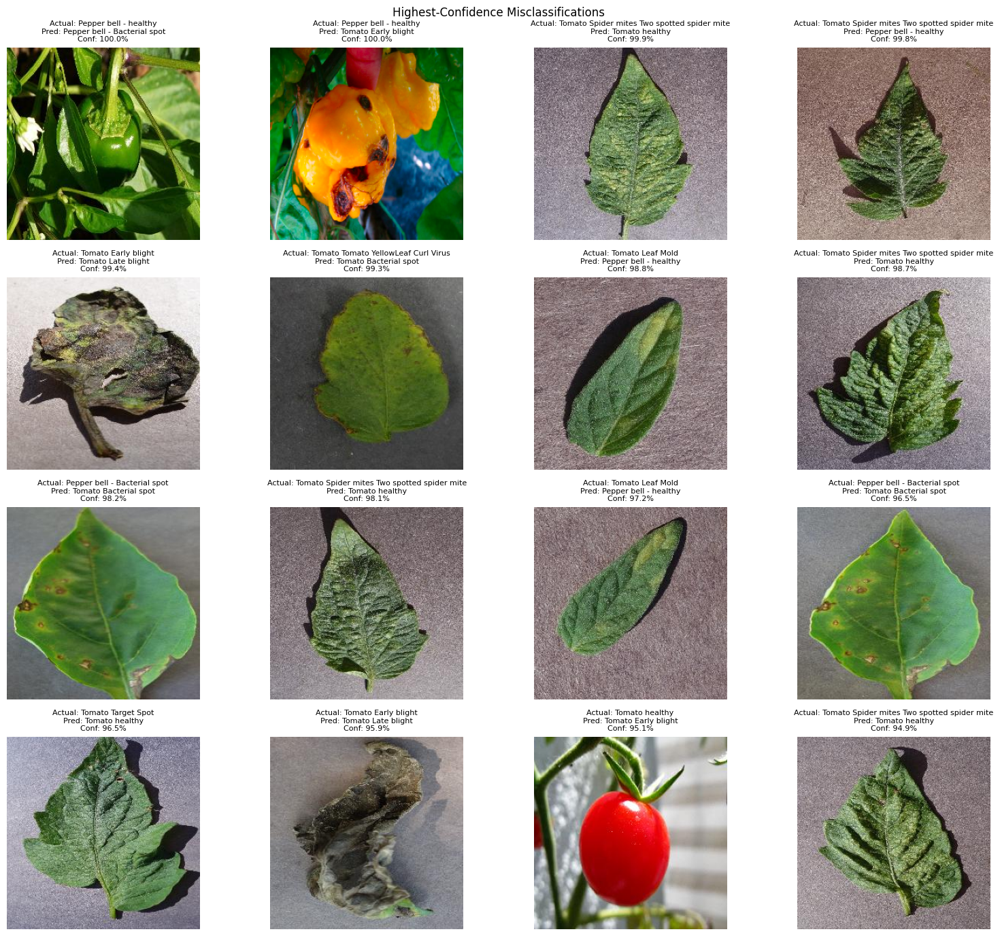

In [35]:
wrong = np.where(y_test != y_pred)[0]
test_paths = test_df["filepath"].values

print("Misclassified:", len(wrong), "/", len(y_test))

if len(wrong):
    # Highest-confidence errors are especially useful to inspect.
    wrong_conf = y_prob[wrong, y_pred[wrong]]
    chosen = wrong[np.argsort(wrong_conf)[::-1][:16]]

    rows = int(np.ceil(len(chosen)/4))
    plt.figure(figsize=(16, rows*3.5))

    for n, idx in enumerate(chosen):
        img = Image.open(test_paths[idx]).convert("RGB")
        actual = READABLE_NAMES[y_test[idx]]
        predicted = READABLE_NAMES[y_pred[idx]]
        conf = y_prob[idx, y_pred[idx]]

        plt.subplot(rows,4,n+1)
        plt.imshow(img)
        plt.title(
            f"Actual: {actual}\nPred: {predicted}\nConf: {conf:.1%}",
            fontsize=8
        )
        plt.axis("off")

    plt.suptitle("Highest-Confidence Misclassifications")
    plt.tight_layout(); plt.show()

In [36]:
# Most common confusion pairs
pairs = []
for true_i in range(NUM_CLASSES):
    for pred_i in range(NUM_CLASSES):
        if true_i != pred_i and cm[true_i, pred_i] > 0:
            pairs.append({
                "Actual": READABLE_NAMES[true_i],
                "Predicted": READABLE_NAMES[pred_i],
                "Count": int(cm[true_i, pred_i])
            })

confusion_pairs = pd.DataFrame(pairs).sort_values("Count", ascending=False)
display(confusion_pairs.head(15))

,Actual,Predicted,Count
24,Tomato Spider mites Two spotted spider mite,Tomato healthy,11
14,Tomato Late blight,Potato - Late blight,10
27,Tomato Tomato YellowLeaf Curl Virus,Tomato Bacterial spot,8
25,Tomato Target Spot,Tomato healthy,5
22,Tomato Spider mites Two spotted spider mite,Tomato Target Spot,4
10,Tomato Early blight,Potato - Early blight,3
17,Tomato Leaf Mold,Tomato Late blight,3
13,Tomato Early blight,Tomato Late blight,3
11,Tomato Early blight,Potato - Late blight,3
16,Tomato Leaf Mold,Pepper bell - healthy,2


### Error Analysis

Analysis of the most frequent misclassifications revealed that the model's errors
were not distributed uniformly across the 15 classes. Instead, several systematic
confusion patterns were observed.

The largest source of error involved Tomato Early blight being classified as Tomato
Late blight. This occurred for 21 test images. Tomato Early blight had 150 test
samples and a recall of 0.8067, corresponding to approximately 29 missed samples.
Therefore, approximately 72% of the missed Tomato Early blight samples were
classified specifically as Tomato Late blight. This explains much of the relatively
low F1-score of 0.8897 observed for Tomato Early blight.

The second most frequent error involved Tomato Spider mites being classified as
Tomato Target Spot, occurring for 19 images. This finding is consistent with the
class-specific metrics: Spider mites had a comparatively lower recall of 0.9087,
while Target Spot achieved very high recall (0.9952) but lower precision (0.9048).
Incorrect Spider-mite predictions therefore contributed to false-positive Target
Spot classifications.

Other notable errors included Tomato Yellow Leaf Curl Virus being classified as
Tomato Spider mites (8 images) and Tomato Bacterial spot (5 images). Tomato Late
blight was also confused with Potato Late blight in 5 cases, while the reverse
confusion occurred in 2 cases.

Many of the most frequent errors occurred between different disease categories of
the same host plant, particularly tomato. This suggests that fine-grained
discrimination between visually related tomato disease categories represents a
greater challenge for the model than many broader class distinctions.

The confusion between Tomato and Potato Late blight also provides an interesting
observation. One possible interpretation is that disease-related visual patterns may
sometimes influence predictions in addition to plant-specific characteristics.
However, the present evaluation cannot determine which visual features caused these
predictions, and explainability methods would be required to investigate this
hypothesis directly.

Overall, the error analysis demonstrates that the model achieved strong performance
but retained specific and interpretable weaknesses. In particular, improving
discrimination between Tomato Early blight and Tomato Late blight, and between
Tomato Spider mites and Tomato Target Spot, would be priorities for future model
development.

## Prototype: classify a single leaf image

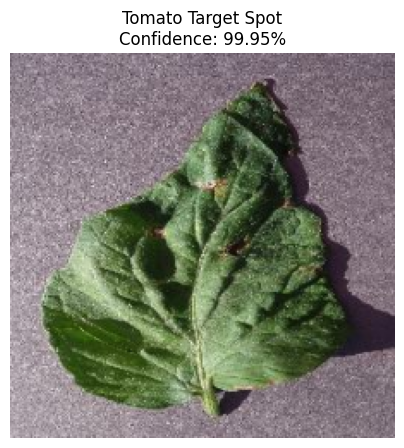

,Class,Probability
11,Tomato Target Spot,99.95%
14,Tomato healthy,0.03%
6,Tomato Early blight,0.01%
10,Tomato Spider mites Two spotted spider mite,0.00%
0,Pepper bell - Bacterial spot,0.00%


,Class,Probability
11,Tomato Target Spot,9.995358e-01
14,Tomato healthy,3.100461e-04
6,Tomato Early blight,1.041003e-04
10,Tomato Spider mites Two spotted spider mite,3.597827e-05
0,Pepper bell - Bacterial spot,1.141408e-05
9,Tomato Septoria leaf spot,1.543916e-06
7,Tomato Late blight,4.987577e-07
1,Pepper bell - healthy,4.087454e-07
5,Tomato Bacterial spot,1.746375e-07
2,Potato - Early blight,3.220595e-08


In [37]:
def predict_leaf(image_path, model=final_model):
    raw = tf.io.read_file(image_path)
    image = tf.io.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    probs = model.predict(tf.expand_dims(image,0), verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    plt.figure(figsize=(5,5))
    plt.imshow(tf.cast(tf.clip_by_value(image,0,255), tf.uint8))
    plt.axis("off")
    plt.title(f"{READABLE_NAMES[pred_idx]}\nConfidence: {probs[pred_idx]:.2%}")
    plt.show()

    ranking = pd.DataFrame({
        "Class": READABLE_NAMES,
        "Probability": probs
    }).sort_values("Probability", ascending=False)

    display(ranking.head(5).style.format({"Probability":"{:.2%}"}))
    return ranking

# Demonstration using an untouched test image:
predict_leaf(test_df.iloc[0]["filepath"])

In [38]:
MODEL_PATH = "/kaggle/working/final_plant_disease_model.keras"
RESULTS_PATH = "/kaggle/working/experiment_results.csv"
PER_CLASS_PATH = "/kaggle/working/final_per_class_results.csv"

final_model.save(MODEL_PATH)
results_df.to_csv(RESULTS_PATH, index=False)
per_class.to_csv(PER_CLASS_PATH, index=False)

print(MODEL_PATH)
print(RESULTS_PATH)
print(PER_CLASS_PATH)

/kaggle/working/final_plant_disease_model.keras
/kaggle/working/experiment_results.csv
/kaggle/working/final_per_class_results.csv
